In [1]:
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spacy

In [2]:
metadata_df = pd.read_csv("../data/manifestos/metadata.csv", index_col="id")

In [3]:
metadata_df.columns

Index(['date', 'subject', 'title', 'contexte-election', 'contexte-tour',
       'cote', 'departement', 'departement-nom', 'departement-insee',
       'identifiant de circonscription', 'images', 'pdf', 'ocr_url',
       'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age',
       'titulaire-age-calcule', 'titulaire-age-tranche',
       'titulaire-profession', 'titulaire-mandat-en-cours',
       'titulaire-mandat-passe', 'titulaire-associations',
       'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste',
       'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom',
       'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule',
       'suppleant-age-tranche', 'suppleant-profession',
       'suppleant-mandat-en-cours', 'suppleant-mandat-passe',
       'suppleant-associations', 'suppleant-autres-statuts',
       'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations'],
      dtype='str')

In [4]:
metadata_df

,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,identifiant de circonscription,...,suppleant-age-calcule,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations
id,,,,,,,,,,,,,,,,,,,,,
EL123_P_1981_001,1981-04-26,France; Elections présidentielles; Ve Républiq...,Election présidentielle de 1981 : profession d...,présidentielle,1,EL123,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EL123_P_1981_002,1981-04-26,France; Elections présidentielles; Ve Républiq...,Election présidentielle de 1981 : profession d...,présidentielle,1,EL123,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EL123_P_1981_003,1981-04-26,France; Elections présidentielles; Ve Républiq...,Election présidentielle de 1981 : profession d...,présidentielle,1,EL123,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EL123_P_1981_004,1981-04-26,France; Elections présidentielles; Ve Républiq...,Election présidentielle de 1981 : profession d...,présidentielle,1,EL123,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EL123_P_1981_005,1981-04-26,France; Elections présidentielles; Ve Républiq...,Election présidentielle de 1981 : profession d...,présidentielle,1,EL123,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EL198_L_1993_03_095_07_2_PF_02,1993-03-28,Ve République;France;Assemblée Nationale;Élect...,"Élections législatives de 1993, Val-d'Oise - 9...",législatives,2,EL198,95,Val-d'Oise,95 - Val-d'Oise,7.0,...,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non
EL198_L_1993_03_095_08_2_PF_01,1993-03-28,Assemblée Nationale;Élections législatives;Fra...,"Élections législatives de 1993, Val-d'Oise - 9...",législatives,2,EL198,95,Val-d'Oise,95 - Val-d'Oise,8.0,...,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,Rassemblement pour la République;Union pour la...,non mentionné,non
EL198_L_1993_03_095_08_2_PF_02,1993-03-28,France;Ve République;Élections législatives;As...,"Élections législatives de 1993, Val-d'Oise - 9...",législatives,2,EL198,95,Val-d'Oise,95 - Val-d'Oise,8.0,...,non mentionné,non mentionné,non mentionné,maire,député,non mentionné,non mentionné,non mentionné,non mentionné,non


In [5]:
def map_political_blocs_temporal(row):
    label = str(row["titulaire-soutien"]).lower()
    year = row["date"].year

    if pd.isna(label) or label == "non mentionné":
        return "UNKNOWN"

    # 1. Left and Far-Right (Stable across 1981-1993)
    if "communiste français" in label:
        return "LEFT_PCF"
    if "front national" in label:
        return "FAR_RIGHT_FN"
    if any(
        x in label for x in ["parti socialiste", "socialiste", "radicaux de gauche"]
    ):
        return "LEFT_PS"
    if any(x in label for x in ["verts", "écologie", "écologiste"]):
        return "ECO"
    if any(x in label for x in ["lutte ouvrière", "ligue communiste"]):
        return "FAR_LEFT"

    # 2. The Right-Wing Bloc (Time-Conditional)
    is_rpr = "rassemblement pour la république" in label
    is_udf = "union pour la démocratie française" in label

    if is_rpr and is_udf:
        # Explicit alliances
        if year == "1981":
            return "RIGHT_UNM"  # Union pour la nouvelle majorité
        if year == "1988":
            return "RIGHT_URC"  # Union du Rassemblement et du Centre
        if year == "1993":
            return "RIGHT_UPF"  # Union pour la France
    elif is_rpr:
        return "RIGHT_RPR"
    elif is_udf:
        return "RIGHT_UDF"

    return "OTHER"

In [6]:
metadata_df["date"] = pd.to_datetime(metadata_df["date"])
metadata_df["target_label"] = metadata_df.apply(map_political_blocs_temporal, axis=1)
main_parties_metadata_df = metadata_df[
    ~metadata_df["target_label"].str.contains("UNKNOWN|OTHER")
]
main_parties_metadata_df = main_parties_metadata_df[
    main_parties_metadata_df["contexte-election"] == "législatives"
]
main_parties_metadata_df.groupby("target_label")["target_label"].count()

target_label
ECO             1184
FAR_LEFT         497
FAR_RIGHT_FN    1242
LEFT_PCF        1605
LEFT_PS         1563
RIGHT_RPR        271
RIGHT_UDF        254
Name: target_label, dtype: int64

In [7]:
main_parties_metadata_df.assign(year=main_parties_metadata_df["date"].dt.year).groupby(
    "year"
).count()

,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,identifiant de circonscription,...,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations,target_label
year,,,,,,,,,,,,,,,,,,,,,
1981,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,...,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997
1988,1434,1434,1434,1434,1434,1434,1434,1434,1434,1434,...,1434,1434,1434,1434,1434,1434,1434,1434,1434,1434
1993,3185,3185,3185,3185,3185,3185,3185,3185,3185,3185,...,3185,3185,3185,3185,3185,3185,3185,3185,3185,3185


In [8]:
main_parties_metadata_df

,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,identifiant de circonscription,...,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations,target_label
id,,,,,,,,,,,,,,,,,,,,,
EL134_L_1981_06_001_01_1_PF_01,1981-06-14,France;Assemblée Nationale;Ve République;Élect...,"Élections législatives de 1981, Ain - 01, circ...",législatives,1,EL134,01,Ain,01 - Ain,1.0,...,non mentionné,infirmière,non mentionné,non mentionné,syndicat,non mentionné,Parti socialiste unifié,non mentionné,non,LEFT_PS
EL134_L_1981_06_001_01_1_PF_02,1981-06-14,Élections législatives;Ve République;Assemblée...,"Élections législatives de 1981, Ain - 01, circ...",législatives,1,EL134,01,Ain,01 - Ain,1.0,...,non mentionné,non mentionné,maire-adjoint,non mentionné,syndicat,non mentionné,Parti communiste français,Union de la gauche,non,LEFT_PCF
EL134_L_1981_06_001_01_1_PF_03,1981-06-14,Élections législatives;Ve République;France;As...,"Élections législatives de 1981, Ain - 01, circ...",législatives,1,EL134,01,Ain,01 - Ain,1.0,...,non mentionné,docteur,non mentionné,non mentionné,non mentionné,non mentionné,Parti socialiste;Mouvement des radicaux de gauche,non mentionné,non,LEFT_PS
EL134_L_1981_06_001_01_1_PF_04,1981-06-14,Assemblée Nationale;France;Ve République;Élect...,"Élections législatives de 1981, Ain - 01, circ...",législatives,1,EL134,01,Ain,01 - Ain,1.0,...,non mentionné,commerçant,non mentionné,non mentionné,culture;politique,non mentionné,Fédération des socialistes démocrates,non mentionné,non,LEFT_PS
EL134_L_1981_06_001_02_1_PF_02,1981-06-14,France;Élections législatives;Ve République;As...,"Élections législatives de 1981, Ain - 01, circ...",législatives,1,EL134,01,Ain,01 - Ain,2.0,...,entre 50 et 59 ans,cadre supérieur SNCF,maire,non mentionné,non mentionné,non mentionné,Parti communiste français,Union de la gauche,non,LEFT_PCF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EL198_L_1993_03_095_03_2_PF_02,1993-03-28,Ve République;Élections législatives;Assemblée...,"Élections législatives de 1993, Val-d'Oise - 9...",législatives,2,EL198,95,Val-d'Oise,95 - Val-d'Oise,3.0,...,non mentionné,non mentionné,conseiller général;maire,non mentionné,non mentionné,non mentionné,Union pour la démocratie française,Opposition,non,RIGHT_UDF
EL198_L_1993_03_095_04_2_PF_02,1993-03-28,France;Assemblée Nationale;Ve République;Élect...,"Élections législatives de 1993, Val-d'Oise - 9...",législatives,2,EL198,95,Val-d'Oise,95 - Val-d'Oise,4.0,...,entre 60 et 69 ans,non mentionné,conseiller municipal,non mentionné,non mentionné,retraité,Front national,non mentionné,non,FAR_RIGHT_FN
EL198_L_1993_03_095_06_2_PF_02,1993-03-28,Ve République;Assemblée Nationale;France;Élect...,"Élections législatives de 1993, Val-d'Oise - 9...",législatives,2,EL198,95,Val-d'Oise,95 - Val-d'Oise,6.0,...,entre 50 et 59 ans,cadre commercial,conseiller municipal,non mentionné,politique,non mentionné,Front national,non mentionné,non,FAR_RIGHT_FN


In [9]:
districts = pd.read_csv("../data/gazetteers/v_arrondissement_2025.csv")["LIBELLE"]
cities = pd.read_csv("../data/gazetteers/v_commune_2025.csv")["LIBELLE"]
overseas_cities = pd.read_csv("../data/gazetteers/v_commune_comer_2025.csv")["LIBELLE"]
departments = pd.read_csv("../data/gazetteers/v_departement_2025.csv")["LIBELLE"]
regions = pd.read_csv("../data/gazetteers/v_region_2025.csv")["LIBELLE"]
overseas_regions = pd.read_csv("../data/gazetteers/v_comer_2025.csv")["LIBELLE"]
raw_gazetteer = pd.concat(
    [districts, cities, overseas_cities, departments, regions, overseas_regions]
).dropna()

In [10]:
def strip_accents(text: str) -> str:
    """Normalize diacritics to mitigate OCR-induced accent-dropping."""
    return "".join(
        c
        for c in unicodedata.normalize("NFKD", text)
        if unicodedata.category(c) != "Mn"
    )


In [11]:
from typing import List, Set


def build_rigorous_gazetteer(file_paths: List[str]) -> Set[str]:
    """
    Constructs a deterministic geographical exclusion set by aggregating
    INSEE COG administrative files while protecting overlapping political ontology.
    """
    # Encapsulated Semantic Safeguards
    POLITICAL_SAFE_WORDS = {
        "nouvelle",
        "nouveau",
        "grand",
        "grande",
        "centre",
        "pays",
        "nord",
        "sud",
        "est",
        "ouest",
        "union",
        "val",
        "haute",
        "hauts",
        "bas",
    }

    # 1. Memory-efficient concatenated loading
    series_list = []
    for path in file_paths:
        # Strictly load the required column to minimize RAM overhead
        try:
            df = pd.read_csv(path, usecols=["LIBELLE"])
            series_list.append(df["LIBELLE"])
        except ValueError:
            raise RuntimeError(f"Column 'LIBELLE' not found in {path}")

    # Combine and drop nulls
    raw_gazetteer = pd.concat(series_list, ignore_index=True).dropna()

    gazetteer = set()

    # 2. Compile regex strictly ONCE outside the loop for O(N) efficiency
    tokenizer = re.compile(r"\b[a-z]{3,}\b")

    # 3. Extract and normalize
    for name in raw_gazetteer:
        # Assumes strip_accents() is defined in your global scope
        norm_name = strip_accents(name.lower())
        tokens = tokenizer.findall(norm_name)

        for token in tokens:
            if token not in POLITICAL_SAFE_WORDS:
                gazetteer.add(token)

    return gazetteer

In [12]:
insee_files = [
    "../data/gazetteers/v_arrondissement_2025.csv",
    "../data/gazetteers/v_commune_2025.csv",
    "../data/gazetteers/v_commune_comer_2025.csv",
    "../data/gazetteers/v_departement_2025.csv",
    "../data/gazetteers/v_region_2025.csv",
    "../data/gazetteers/v_comer_2025.csv",
]
GAZETTEER = build_rigorous_gazetteer(insee_files)

In [13]:
try:
    nlp = spacy.load("fr_core_news_lg", disable=["parser"])
except OSError:
    raise RuntimeError("Run: python -m spacy download fr_core_news_lg")

DISCOURSE_MARKERS = {
    "madame",
    "monsieur",
    "mademoiselle",
    "électrice",
    "électeur",
    "concitoyen",
    "cher",
    "chère",
    "salutation",
    "dévoué",
    "fidèle",
    "candidat",
    "circonscription",
    "vote",
    "voter",
    "élection",
    "scrutin",
    "tour",
    "premier",
    "deuxième",
    "suppléant",
    "bulletin",
    "suffrage",
    "député",
    "canton",
    "maire",
    "sortant",
    "mandat",
    "assemblée",
    "vouloir",
    "pouvoir",
    "devoir",
    "faire",
    "falloir",
    "mettre",
    "aller",
    "agir",
    "savoir",
    "répondre",
    "attendre",
    "permettre",
    "croire",
    "ici",
    "oui",
    "non",
    "beaucoup",
    "ensemble",
    "bien",
    "toujours",
    "aujourd'hui",
    "maintenant",
    "ainsi",
    "plus",
    "moins",
    "année",
    "suite",
    "jour",
    "nouveau",
    "nouvelle",
    "fois",
    "moment",
    "cadre",
    "objet",
    "point",
    "particulier",
    "notamment",
}

DISCOURSE_MARKERS_NORMALIZED = {strip_accents(w).lower() for w in DISCOURSE_MARKERS}


def clean_archelec_manifesto(text: str) -> str:
    """
    Sanitizes manifestos to create a stationary feature space by neutralizing
    OCR noise, geographical leakage, protecting acronyms, and tracking negation.
    """
    if not isinstance(text, str):
        return ""

    # 0. Acronym Stitching (Execute BEFORE spaCy to bypass length thresholds)
    text = re.sub(r"\bP\.?\s*S\.?\b", "parti_socialiste", text, flags=re.IGNORECASE)
    text = re.sub(r"\bP\.?\s*C\.?\b", "parti_communiste", text, flags=re.IGNORECASE)
    text = re.sub(r"\bR\.?\s*P\.?\s*R\.?\b", "rpr", text, flags=re.IGNORECASE)
    text = re.sub(r"\bU\.?\s*D\.?\s*F\.?\b", "udf", text, flags=re.IGNORECASE)

    # 1. OCR Hyphenation & Archival Noise Correction
    text = re.sub(r"-\s+", "", text)
    text = re.sub(r"(?i)sciences\s*po\s*/\s*fonds\s*cevipof", "", text)
    text = re.sub(r"(?i)imprimer[il]e\s+[^\n]+", "", text)
    text = re.sub(r"(?i)vu\s+les\s+candidats?", "", text)

    doc = nlp(text)
    sanitized_tokens = []
    negation_active = False  # State tracker for semantic inversion

    for token in doc:
        # A. Reset negation state on clause boundaries to prevent contamination
        if token.is_punct:
            negation_active = False
            continue

        # B. Trigger negation state
        if token.lemma_.lower() in ["ne", "n'"]:
            negation_active = True
            continue

        # C. Filter Spatial/Biographical Data Leakage
        if token.ent_type_ in ["LOC", "PER"]:
            continue

        # D. Morphosyntactic Filtering
        if token.pos_ not in ["NOUN", "ADJ", "VERB", "PROPN"]:
            continue

        lemma_norm = strip_accents(token.lemma_.lower())

        # E. Purge Auxiliaries, Gazetteer, and Null-Variance Markers
        if lemma_norm in ["etre", "avoir"]:
            continue

        if lemma_norm in GAZETTEER or lemma_norm in DISCOURSE_MARKERS_NORMALIZED:
            continue

        if token.is_stop or token.is_space:
            continue

        # F. Residual OCR Scoria Filter
        if len(lemma_norm) < 3 or not lemma_norm.isalpha():
            continue

        # G. Apply ideological inversion prefix to the FIRST surviving semantic token
        if negation_active:
            lemma_norm = "ne_" + lemma_norm
            negation_active = False

        sanitized_tokens.append(lemma_norm)

    return " ".join(sanitized_tokens)

In [14]:
manifesto_eg = main_parties_metadata_df.index[440]
with open(f"../data/manifestos/1981/legislatives/{manifesto_eg}.txt", "r") as f:
    print(f.read())

ensemble
le 14 juin confirmons l'espoir du 10 mai
1er circonscription Montpellier-Lunel
République Française - Département de l'Hérault Elections législatives de juin 1981
GEORGES FRÊCHE
Maire de Montpellier Professeur à la Faculté de Droit
Suppléant : Elie RAUZIER Maire de Lunel, ingénieur
Parti socialiste
Au soir du 10 Mai François Mitterrand, notre Président, déclarait : « nous avons tant de choses à faire ensemble ». Donnons-lui la majorité qui lui permettra de les réaliser. Donnons à la France les députés socialistes dont elle a besoin. L'élan est donné. La France repart, la France revit, la France retrouve sa jeunesse. Ensemble continuons notre chemin avec le Président, avec la majorité de la France. Pour que s'expriment enfin les forces de la vie, les forces de la création, les forces du changement. Ensemble nous allons relancer l'économie. Nous allons donner la priorité à l'emploi. Nous allons construire une France où chacun aura sa place. Ensemble le 14 Juin, confirmons l'imme

In [15]:
manifesto_eg = main_parties_metadata_df.index[440]
with open(f"../data/manifestos/1981/legislatives/{manifesto_eg}.txt", "r") as f:
    text = f.read()
cleaned_text = clean_archelec_manifesto(text)

In [16]:
import textwrap

# Wraps the text cleanly at 80 characters per line
print(textwrap.fill(cleaned_text, width=80))

juin confirmer mai juin george professeur faculte droit ingenieur parti
socialiste soir mai declarer chose donnons majorite realiser donner socialiste
besoin donner repartir revoir retrouver jeunesse continuer president majorite
exprimer creation changement relancer economie donner priorite emploi construire
juin confirmer immense mai tranquillite construire avenir justice social smic
relever tva abaisser produit necessite integration handicape societe dignite
retrouver personne agee avenir liberer droit travailleur droit egal femme statut
femme commercant agriculteur justice independant emploi relance economique
croissance investissement favoriser epargne proteger developpement commercant
artisan paix respecter monde ordre economique mondial solidarite tiers monde
agriculture reforme politique garantie agriculteur face elargissement statut
femme agriculteur garantie revenu viticulteur producteur fruit legume emploi
aide pme pmi vivre travailler pays emploi femme decentralisation regio

In [ ]:
import sys
from pathlib import Path
import pandas as pd
from tqdm.notebook import tqdm

# Dynamically add the repository root to sys.path so we can import 'src'
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Import our custom MLOps modules
from preprocessing.preprocessing import load_and_filter_metadata, ArchelecPreprocessor

# Define data paths
DATA_DIR = PROJECT_ROOT / "data"
MANIFESTOS_DIR = DATA_DIR / "manifestos"
GAZETTEERS_DIR = DATA_DIR / "gazetteers"

print(f"Project Root: {PROJECT_ROOT}")

Project Root: /Users/audricsicard/Documents/VSCode/ML for NLP/Project


In [ ]:
# 1. Load the labels (Ground Truth)
metadata_path = MANIFESTOS_DIR / "metadata.csv"
df_labels = load_and_filter_metadata(metadata_path)

print(f"Loaded {len(df_labels)} legislative manifestos from main political blocs.")
display(df_labels["target_label"].value_counts())

# 2. Initialize the heavy NLP pipeline (spaCy + Gazetteers)
insee_files = [
    GAZETTEERS_DIR / "v_arrondissement_2025.csv",
    GAZETTEERS_DIR / "v_commune_2025.csv",
    GAZETTEERS_DIR / "v_commune_comer_2025.csv",
    GAZETTEERS_DIR / "v_departement_2025.csv",
    GAZETTEERS_DIR / "v_region_2025.csv",
    GAZETTEERS_DIR / "v_comer_2025.csv",
]

preprocessor = ArchelecPreprocessor(insee_files)

Loaded 8110 legislative manifestos from main political blocs.


target_label
LEFT_PCF        1605
LEFT_PS         1563
FAR_RIGHT_FN    1242
ECO             1184
RIGHT_UPF        780
FAR_LEFT         497
RIGHT_URC        493
RIGHT_RPR        271
RIGHT_UDF        254
RIGHT_UNM        221
Name: count, dtype: int64

Initializing spaCy pipeline and compiling gazetteer...


In [ ]:
# Track successful processing and missing files
cleaned_texts = []
valid_indices = []
missing_files = []

# tqdm gives us a beautiful progress bar in the notebook
for doc_id, row in tqdm(
    df_labels.iterrows(), total=len(df_labels), desc="Processing Manifestos"
):
    year = str(row["date"].year)
    # Map the metadata "législatives" to the folder name "legislatives"
    e_type = "legislatives"

    file_path = MANIFESTOS_DIR / year / e_type / f"{doc_id}.txt"

    if file_path.exists():
        with open(file_path, "r", encoding="utf-8") as f:
            raw_text = f.read()

        # Execute our hardened cleaning logic
        cleaned = preprocessor.clean_text(raw_text)

        cleaned_texts.append(cleaned)
        valid_indices.append(doc_id)
    else:
        missing_files.append(doc_id)

print(f"Successfully processed: {len(cleaned_texts)}")
print(f"Missing files dropped: {len(missing_files)}")

# Re-align our DataFrame to drop rows where the text file was missing
df_clean = df_labels.loc[valid_indices].copy()
df_clean["cleaned_text"] = cleaned_texts

# Define our X and y vectors for modeling
X = df_clean["cleaned_text"]
y = df_clean["target_label"]

Processing Manifestos:   0%|          | 0/8110 [00:00<?, ?it/s]

Successfully processed: 8110
Missing files dropped: 0


--- 1. Loading Raw OCR Text for Comparison ---


Fetching Raw Text:   0%|          | 0/8110 [00:00<?, ?it/s]


--- 2. Calculating Compression Metrics ---
Average Raw Words per Manifesto: 651
Average Clean Tokens per Manifesto: 194
Average Noise Removed: 70.5% per document


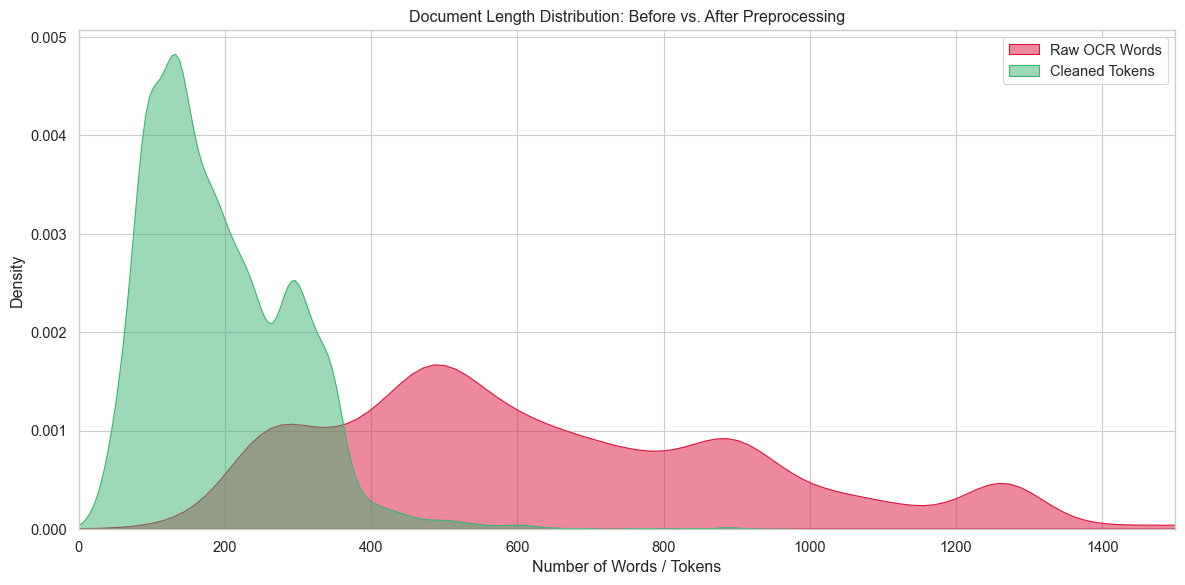


--- 3. Visual Text Verification ---
RAW OCR TEXT (First 300 chars):
--------------------------------------------------
ELECTIONS LEGISLATIVES - 14 JUIN 1981 AIN 1e CIRCONSCRIPTION
Micheline ANTONUCCI
POUR QUE ÇA DURE ...
La victoire de François Mitterrand, le 10 mai, a exprimé la volonté de changement de la grande majorité des travailleurs, des hommes et des femmes de ce pays.
Les élections législatives sont une éta...

PREPROCESSED TEXT (First 300 chars):
--------------------------------------------------
legislative dur exprimer volonte changement grand majorite travailleur femme pays legislatif important consolidation majorite gauche adjoint assistant social gauche condition essentiel reconnaissance pluralisme respecter difference politique gauche necessaire eviter alliance centriste reduire entend...


In [ ]:
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

print("--- 1. Loading Raw OCR Text for Comparison ---")
# Assuming df_clean already has the 'cleaned_text' and 'target_label'
raw_texts = []
for doc_id, row in tqdm(
    df_clean.iterrows(), total=len(df_clean), desc="Fetching Raw Text"
):
    year = str(row["date"].year)
    file_path = MANIFESTOS_DIR / year / "legislatives" / f"{doc_id}.txt"
    if file_path.exists():
        with open(file_path, "r", encoding="utf-8") as f:
            raw_texts.append(f.read())
    else:
        raw_texts.append("")  # Fallback, though we already filtered valid indices

df_clean["raw_text"] = raw_texts

print("\n--- 2. Calculating Compression Metrics ---")
df_clean["raw_length"] = df_clean["raw_text"].apply(lambda x: len(str(x).split()))
df_clean["clean_length"] = df_clean["cleaned_text"].apply(lambda x: len(str(x).split()))
df_clean["noise_ratio"] = 1 - (df_clean["clean_length"] / df_clean["raw_length"])

print(f"Average Raw Words per Manifesto: {df_clean['raw_length'].mean():.0f}")
print(f"Average Clean Tokens per Manifesto: {df_clean['clean_length'].mean():.0f}")
print(
    f"Average Noise Removed: {df_clean['noise_ratio'].mean() * 100:.1f}% per document"
)

# Plot the distribution shift
plt.figure(figsize=(12, 6))
sns.kdeplot(
    data=df_clean,
    x="raw_length",
    fill=True,
    label="Raw OCR Words",
    color="crimson",
    alpha=0.5,
)
sns.kdeplot(
    data=df_clean,
    x="clean_length",
    fill=True,
    label="Cleaned Tokens",
    color="mediumseagreen",
    alpha=0.5,
)
plt.title("Document Length Distribution: Before vs. After Preprocessing")
plt.xlabel("Number of Words / Tokens")
plt.ylabel("Density")
plt.xlim(0, 1500)  # Capping x-axis to ignore extreme outliers for readability
plt.legend()
plt.tight_layout()
plt.show()

print("\n--- 3. Visual Text Verification ---")
sample_idx = df_clean.index[0]
print("RAW OCR TEXT (First 300 chars):")
print("-" * 50)
print(str(df_clean.loc[sample_idx, "raw_text"])[:300] + "...")
print("\nPREPROCESSED TEXT (First 300 chars):")
print("-" * 50)
print(str(df_clean.loc[sample_idx, "cleaned_text"])[:300] + "...")

--- 1. Corpus Geometry & Class Balance ---


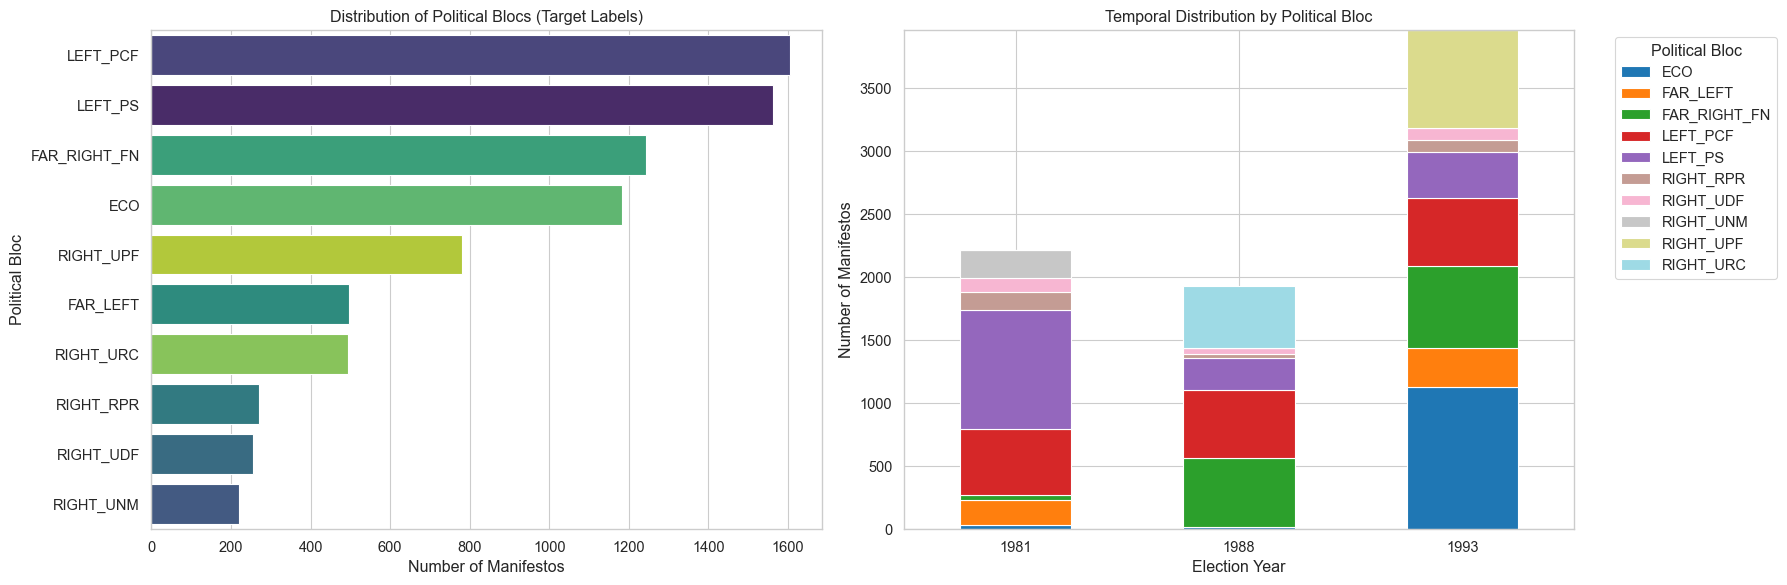


--- 2. Lexical Statistics & Geometry ---
Total documents (N): 8110
Global Vocabulary Size (|V|): 31,747 unique tokens
Average document length: 194 tokens (Median: 174)
Average UNIQUE tokens per doc: 149
Lexical Richness Ratio: 0.77 (Unique/Total)


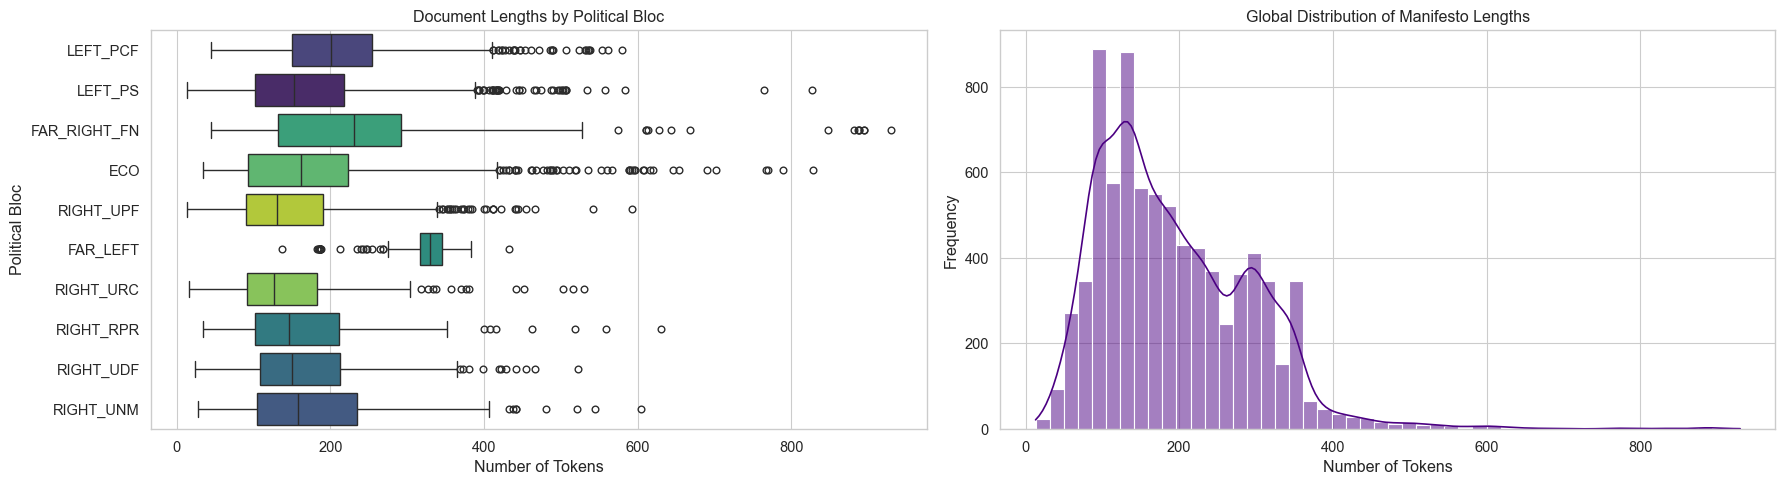


--- 3. Semantic Signatures: Top 10 Unigrams ---


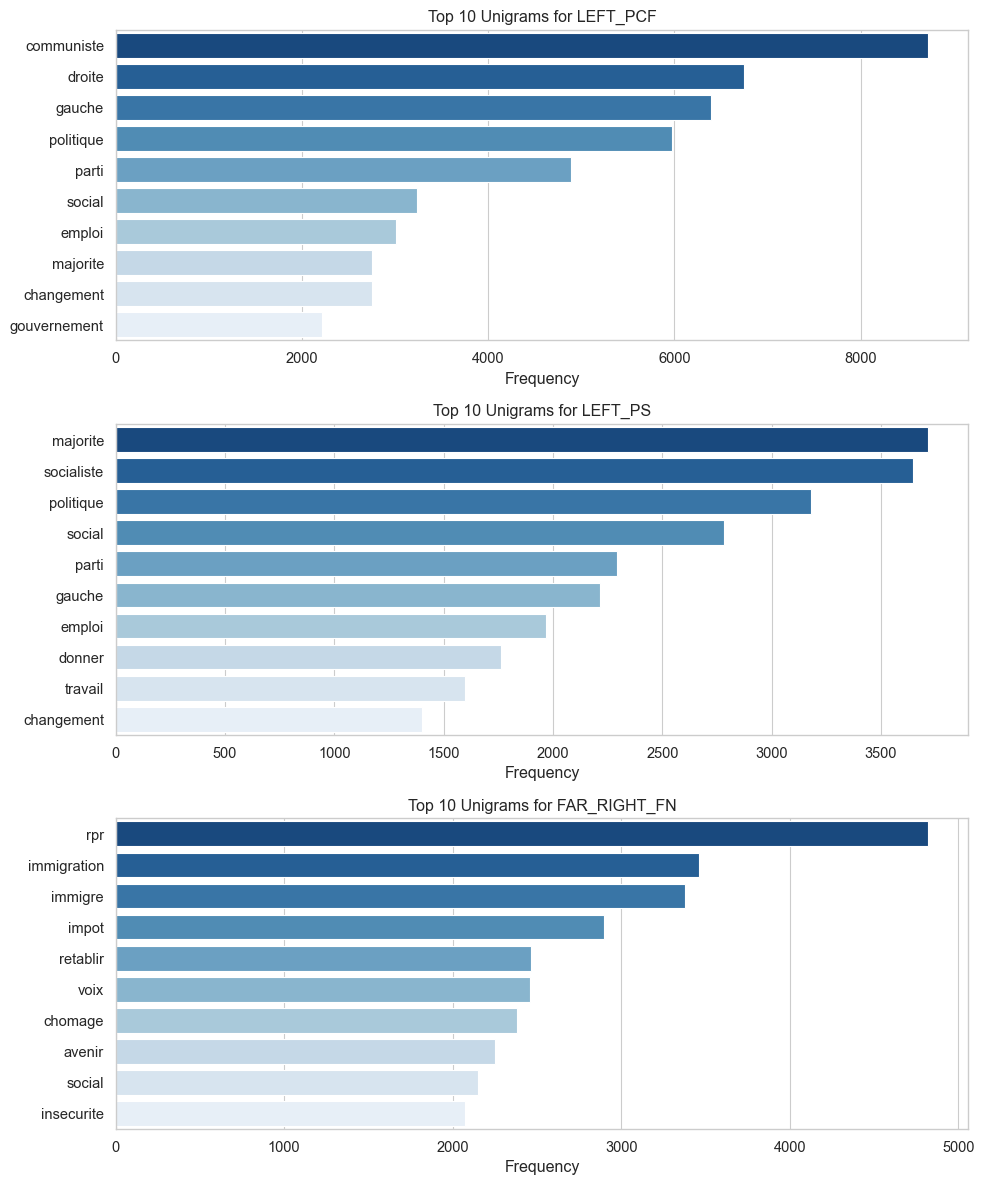


--- 3. Semantic Signatures: Top 10 Bigrams ---


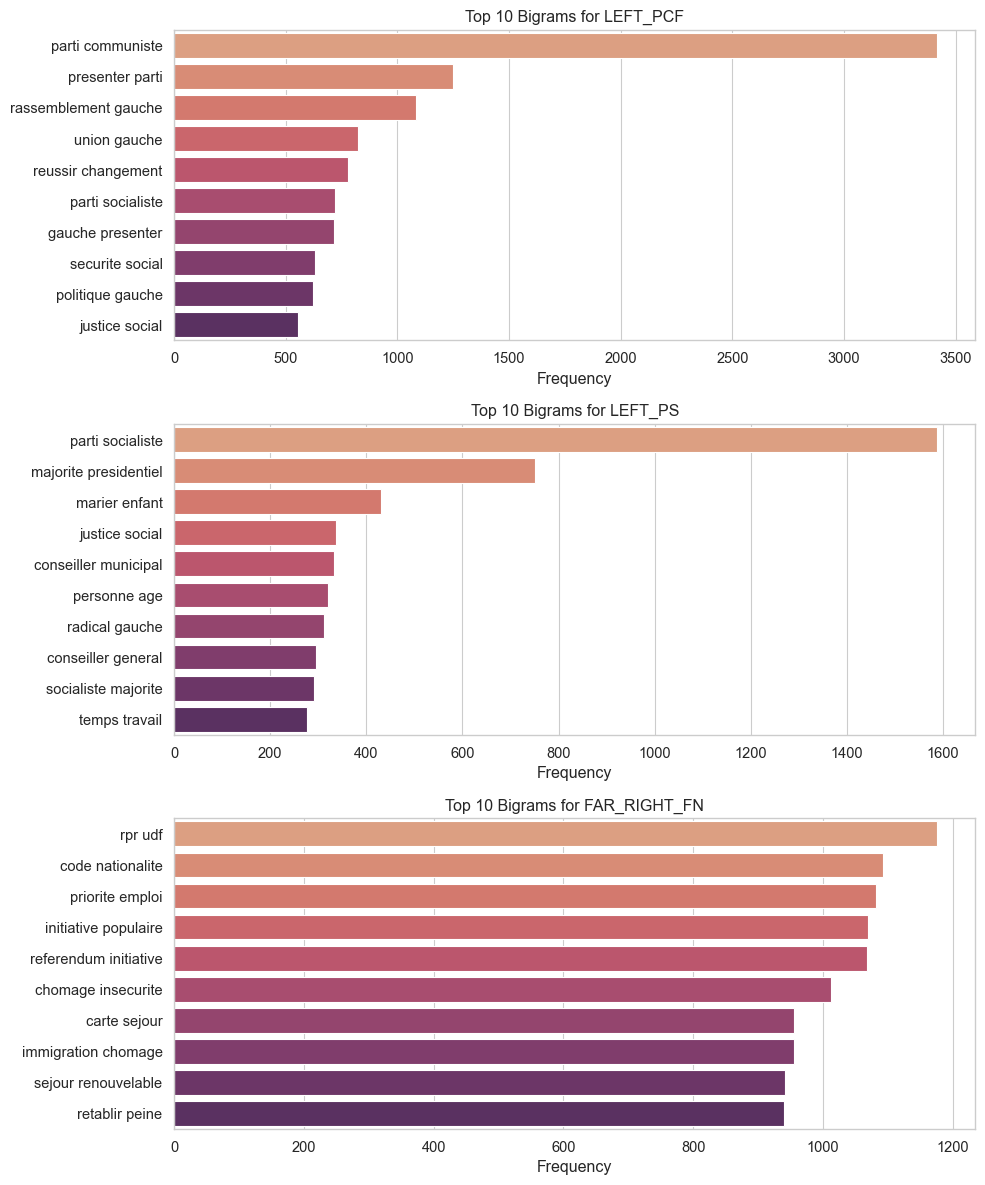

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

# Set academic plotting style globally
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)


def plot_corpus_geometry(
    df: pd.DataFrame, label_col: str = "target_label", date_col: str = "date"
):
    """Plots the macroscopic class balance and diachronic temporal distribution."""
    print("--- 1. Corpus Geometry & Class Balance ---")

    # Extract year if not present
    if "year" not in df.columns:
        df["year"] = pd.to_datetime(df[date_col]).dt.year

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    order = df[label_col].value_counts().index

    # 1A. Class Distribution (Warning Fixed: hue=label_col, legend=False)
    sns.countplot(
        data=df,
        y=label_col,
        order=order,
        hue=label_col,
        palette="viridis",
        legend=False,
        ax=axes[0],
    )
    axes[0].set_title("Distribution of Political Blocs (Target Labels)")
    axes[0].set_xlabel("Number of Manifestos")
    axes[0].set_ylabel("Political Bloc")

    # 1B. Temporal Distribution
    temporal_counts = pd.crosstab(df["year"], df[label_col])
    temporal_counts.plot(kind="bar", stacked=True, colormap="tab20", ax=axes[1])
    axes[1].set_title("Temporal Distribution by Political Bloc")
    axes[1].set_xlabel("Election Year")
    axes[1].set_ylabel("Number of Manifestos")
    axes[1].legend(title="Political Bloc", bbox_to_anchor=(1.05, 1), loc="upper left")
    axes[1].tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()


def plot_lexical_statistics(
    df: pd.DataFrame, text_col: str = "cleaned_text", label_col: str = "target_label"
):
    """Computes document lengths, vocabulary size |V|, and plots lexical distributions."""
    print("\n--- 2. Lexical Statistics & Geometry ---")

    # Compute metrics
    df["doc_length"] = df[text_col].apply(lambda x: len(x.split()))
    df["unique_tokens"] = df[text_col].apply(lambda x: len(set(x.split())))
    order = df[label_col].value_counts().index

    # Compute Global |V|
    global_vec = CountVectorizer()
    global_vec.fit(df[text_col])
    vocab_size = len(global_vec.vocabulary_)

    print(f"Total documents (N): {len(df)}")
    print(f"Global Vocabulary Size (|V|): {vocab_size:,} unique tokens")
    print(
        f"Average document length: {df['doc_length'].mean():.0f} tokens (Median: {df['doc_length'].median():.0f})"
    )
    print(f"Average UNIQUE tokens per doc: {df['unique_tokens'].mean():.0f}")
    print(
        f"Lexical Richness Ratio: {df['unique_tokens'].mean() / df['doc_length'].mean():.2f} (Unique/Total)"
    )

    # Plot Distributions
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    # 2A. Lengths by Bloc (Warning Fixed: hue=label_col, legend=False)
    sns.boxplot(
        data=df,
        x="doc_length",
        y=label_col,
        order=order,
        hue=label_col,
        palette="viridis",
        legend=False,
        ax=axes[0],
    )
    axes[0].set_title("Document Lengths by Political Bloc")
    axes[0].set_xlabel("Number of Tokens")
    axes[0].set_ylabel("Political Bloc")

    # 2B. Global Length Histogram
    sns.histplot(data=df, x="doc_length", bins=50, kde=True, color="indigo", ax=axes[1])
    axes[1].set_title("Global Distribution of Manifesto Lengths")
    axes[1].set_xlabel("Number of Tokens")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()


def plot_top_ngrams_per_class(
    df: pd.DataFrame,
    text_col: str = "cleaned_text",
    label_col: str = "target_label",
    ngram_range: tuple = (1, 1),
    top_n: int = 10,
    num_classes: int = 4,
):
    """Dynamically extracts and plots the top n-grams for the most populated classes."""
    ngram_name = (
        "Unigrams"
        if ngram_range == (1, 1)
        else "Bigrams"
        if ngram_range == (2, 2)
        else f"{ngram_range}-grams"
    )
    print(f"\n--- 3. Semantic Signatures: Top {top_n} {ngram_name} ---")

    # Select major classes to keep the plot readable
    major_classes = df[label_col].value_counts().nlargest(num_classes).index
    fig, axes = plt.subplots(
        nrows=len(major_classes), ncols=1, figsize=(10, 4 * len(major_classes))
    )

    if len(major_classes) == 1:
        axes = [axes]

    for ax, target_class in zip(axes, major_classes):
        corpus = df[df[label_col] == target_class][text_col]

        vec = CountVectorizer(ngram_range=ngram_range)
        bag_of_words = vec.fit_transform(corpus)
        sum_words = bag_of_words.sum(axis=0)

        words_freq = [
            (word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()
        ]
        words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_n]
        words, freqs = zip(*words_freq)

        # Warning Fixed: hue=list(words), legend=False
        sns.barplot(
            x=list(freqs),
            y=list(words),
            ax=ax,
            hue=list(words),
            palette="Blues_r" if ngram_range == (1, 1) else "flare",
            legend=False,
        )
        ax.set_title(f"Top {top_n} {ngram_name} for {target_class}")
        ax.set_xlabel("Frequency")

    plt.tight_layout()
    plt.show()


# ==========================================
# Execute the Diagnostics
# ==========================================
plot_corpus_geometry(df_clean)
plot_lexical_statistics(df_clean)

# Unigrams (Check for residual noise)
plot_top_ngrams_per_class(df_clean, ngram_range=(1, 1), top_n=10, num_classes=3)

# Bigrams (Check for ideological signatures)
plot_top_ngrams_per_class(df_clean, ngram_range=(2, 2), top_n=10, num_classes=3)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

print("--- 1. Constructing the TF-IDF Feature Space ---")

# Initialize the vectorizer with our EDA-informed hyperparameters
tfidf = TfidfVectorizer(
    min_df=10,  # Ignore terms appearing in fewer than 5 documents
    max_df=0.85,  # Ignore terms appearing in > 85% of documents
    ngram_range=(1, 2),  # Extract unigrams and bigrams
    sublinear_tf=True,  # Logarithmic term-frequency scaling
    norm="l2",  # Normalize document lengths
)

# Project the text into the mathematical feature space (X)
X = tfidf.fit_transform(df_clean["cleaned_text"])
y = df_clean["target_label"].values
feature_names = np.array(tfidf.get_feature_names_out())

# Calculate matrix sparsity
matrix_size = X.shape[0] * X.shape[1]
non_zero_elements = X.nnz
sparsity = 100 * (1 - (non_zero_elements / matrix_size))

print(f"Number of documents (N): {X.shape[0]}")
print(f"New Vocabulary Size (|V|): {X.shape[1]:,} features (Reduced from ~31,000)")
print(f"Matrix Sparsity: {sparsity:.2f}% (Percentage of zeroes)")


print("\n--- 2. Semantic Verification: Top TF-IDF Features per Bloc ---")
# Unlike CountVectorizer, TF-IDF highlights words that are UNIQUE to a class


def get_top_tfidf_features(X_matrix, y_labels, feature_names_array, top_n=10):
    classes = np.unique(y_labels)

    for target_class in classes:
        # Get the row indices for the current class
        class_indices = np.where(y_labels == target_class)[0]

        # Calculate the mean TF-IDF score for each feature across these documents
        class_mean_tfidf = np.asarray(X_matrix[class_indices].mean(axis=0)).flatten()

        # Get the indices of the top N features
        top_indices = class_mean_tfidf.argsort()[-top_n:][::-1]

        print(f"\n[{target_class}] Top {top_n} Features:")
        for idx in top_indices:
            print(
                f"  - {feature_names_array[idx]:<25} (Score: {class_mean_tfidf[idx]:.4f})"
            )


# Let's look at a few distinct classes to ensure ideological separation
classes_to_check = ["LEFT_PS", "RIGHT_RPR", "FAR_RIGHT_FN", "FAR_LEFT"]
mask = df_clean["target_label"].isin(classes_to_check).values

# Pass the filtered subset to our function
get_top_tfidf_features(X[mask], y[mask], feature_names)

--- 1. Constructing the TF-IDF Feature Space ---
Number of documents (N): 8110
New Vocabulary Size (|V|): 21,985 features (Reduced from ~31,000)
Matrix Sparsity: 98.88% (Percentage of zeroes)

--- 2. Semantic Verification: Top TF-IDF Features per Bloc ---

[FAR_LEFT] Top 10 Features:
  - travailleur               (Score: 0.0646)
  - patron                    (Score: 0.0597)
  - bourgeoisie               (Score: 0.0527)
  - maintenir emploi          (Score: 0.0495)
  - jeter                     (Score: 0.0495)
  - lutte ouvrier             (Score: 0.0467)
  - payer                     (Score: 0.0464)
  - patronat                  (Score: 0.0459)
  - sacrifice                 (Score: 0.0450)
  - employe                   (Score: 0.0448)

[FAR_RIGHT_FN] Top 10 Features:
  - immigre                   (Score: 0.0579)
  - rpr                       (Score: 0.0557)
  - immigration               (Score: 0.0556)
  - insecurite                (Score: 0.0464)
  - peine                     (Score: 

--- 1. Strict Train/Test Split (Preventing Data Leakage) ---
--- 2. TF-IDF Projection ---
Training set dimensions: (6488, 18054)

--- 3. SVM Grid Search Cross-Validation ---
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best Hyperparameters: {'C': 1}
Best CV Macro F1-Score: 0.8345

--- 4. Final Evaluation on Hold-Out Test Set ---
              precision    recall  f1-score   support

         ECO       1.00      0.99      0.99       237
    FAR_LEFT       0.98      1.00      0.99        99
FAR_RIGHT_FN       1.00      0.99      0.99       248
    LEFT_PCF       0.98      0.97      0.98       321
     LEFT_PS       0.94      0.97      0.95       313
   RIGHT_RPR       0.69      0.54      0.60        54
   RIGHT_UDF       0.61      0.33      0.43        51
   RIGHT_UNM       0.70      0.68      0.69        44
   RIGHT_UPF       0.83      0.93      0.88       156
   RIGHT_URC       0.84      0.93      0.88        99

    accuracy                           0.93      1622
   

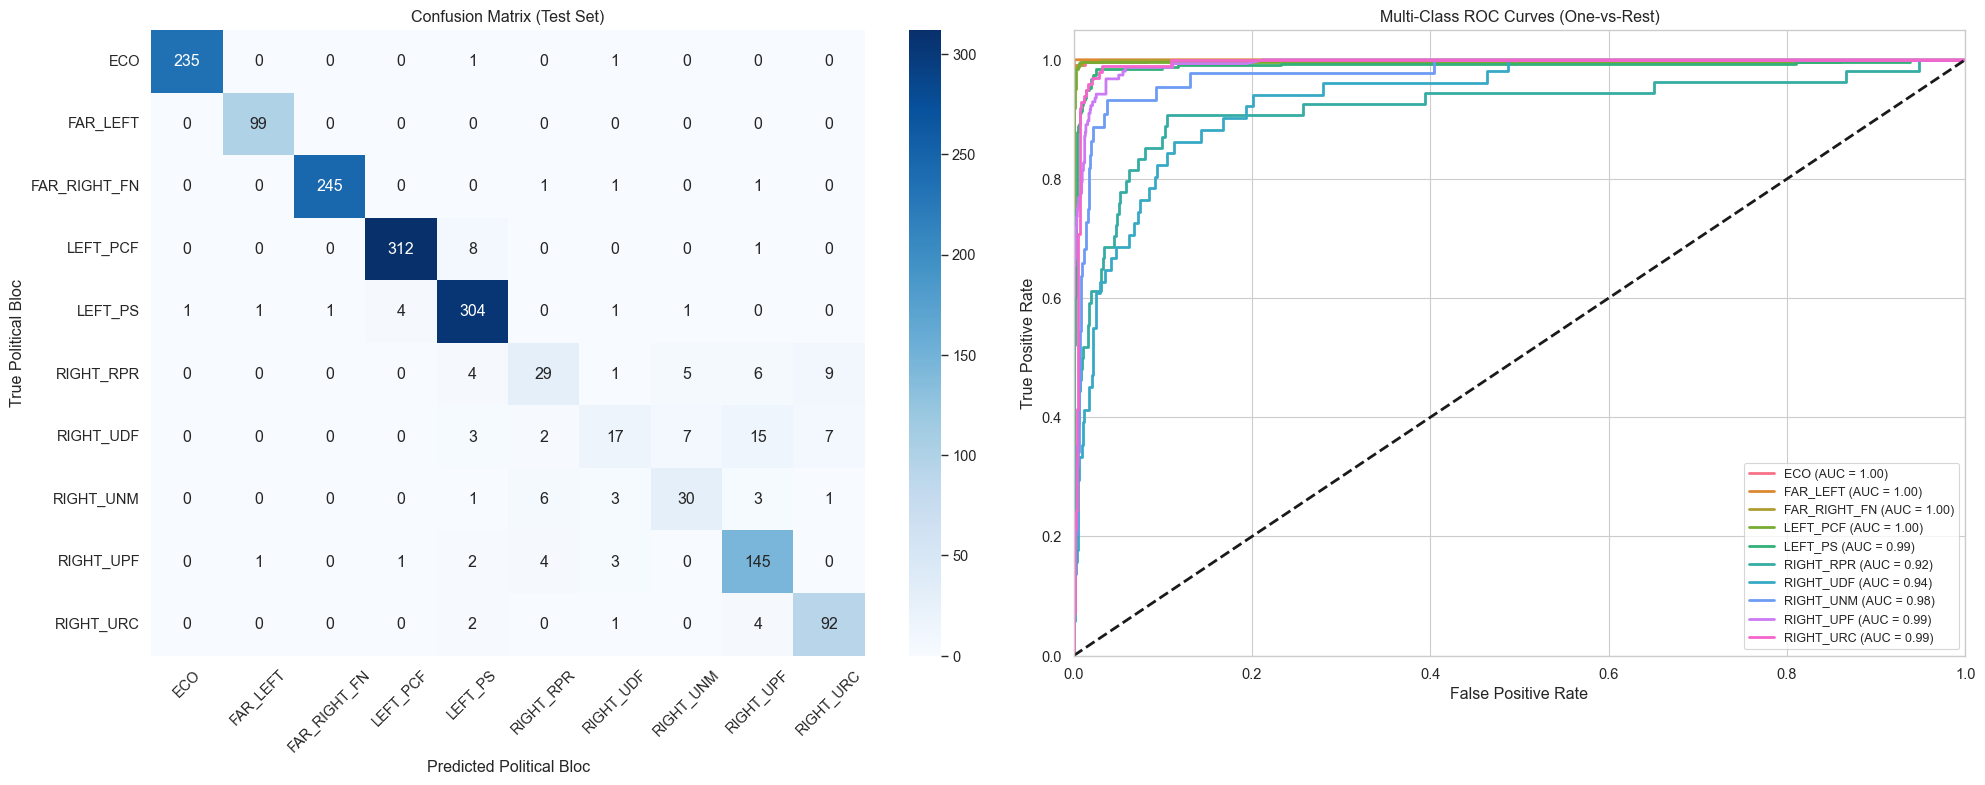

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

print("--- 1. Strict Train/Test Split (Preventing Data Leakage) ---")
X_raw = df_clean["cleaned_text"]
y = df_clean["target_label"].values

# Stratify ensures minor classes (like RIGHT_RPR) are correctly represented in both sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

print("--- 2. TF-IDF Projection ---")
tfidf = TfidfVectorizer(
    min_df=10, max_df=0.85, ngram_range=(1, 2), sublinear_tf=True, norm="l2"
)

# Fit ONLY on train, transform both
X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)
print(f"Training set dimensions: {X_train.shape}")

print("\n--- 3. SVM Grid Search Cross-Validation ---")
# class_weight='balanced' mathematically penalizes mistakes on small classes
svm = LinearSVC(class_weight="balanced", max_iter=2000, random_state=42)

# Define the hyperparameter grid for Regularization (C)
param_grid = {"C": [0.01, 0.1, 1, 10]}

# 5-Fold Stratified Cross Validation optimizing for Macro F1-Score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    svm, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)
best_svm = grid_search.best_estimator_

print(f"\nBest Hyperparameters: {grid_search.best_params_}")
print(f"Best CV Macro F1-Score: {grid_search.best_score_:.4f}")

print("\n--- 4. Final Evaluation on Hold-Out Test Set ---")
y_pred = best_svm.predict(X_test)
print(classification_report(y_test, y_pred))

# ==========================================
# 5. Visual Diagnostics
# ==========================================
classes = np.unique(y)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Plot A: Confusion Matrix ---

cm = confusion_matrix(y_test, y_pred, labels=classes)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix (Test Set)")
axes[0].set_ylabel("True Political Bloc")
axes[0].set_xlabel("Predicted Political Bloc")
axes[0].tick_params(axis="x", rotation=45)

# --- Plot B: Multi-Class ROC Curve (One-vs-Rest) ---
# Binarize the output
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = classes.shape[0]

# SVMs don't output probabilities, but they do output distance from the hyperplane
y_score = best_svm.decision_function(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
colors = sns.color_palette("husl", n_classes)
for i, color in zip(range(n_classes), colors):
    axes[1].plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f"{classes[i]} (AUC = {roc_auc[i]:.2f})",
    )

axes[1].plot([0, 1], [0, 1], "k--", lw=2)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Multi-Class ROC Curves (One-vs-Rest)")
axes[1].legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

Matrix Shape: 6488 documents x 18054 features

--- 3. IDF (Inverse Document Frequency) Distribution ---


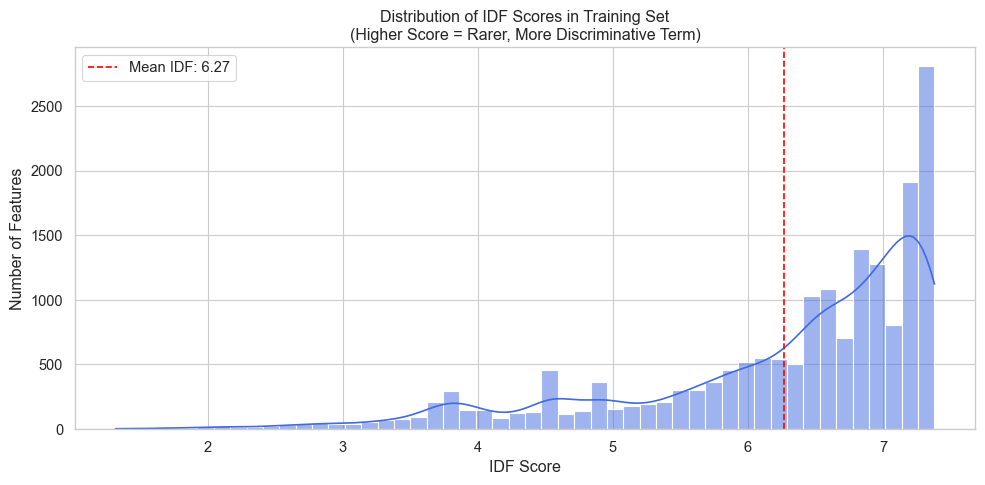


--- 4. The Extremes of the Feature Space ---
Top 10 MOST COMMON features (Lowest IDF - Dangerously close to being stop words):


,Feature,IDF_Score
12268,politique,1.318935
15792,social,1.328735
5798,emploi,1.367810
15994,socialiste,1.547819
11906,pays,1.552628
2276,chomage,1.572099
17017,travail,1.621927
11733,parti,1.667136
3878,defendre,1.688075
1440,avenir,1.697626



Top 10 RAREST features (Highest IDF - Just survived the min_df=10 threshold):


,Feature,IDF_Score
7606,gauche effort,7.379968
16096,socialiste rassemblement,7.379968
12043,pelle departement,7.379968
4435,deuxiem,7.379968
12023,pcf ne_chose,7.379968
12022,pcf conseiller,7.379968
16088,socialiste presidentiel,7.379968
4452,developpement culturel,7.379968
12006,pays œuvre,7.379968
4458,developpement ecologique,7.379968


In [ ]:
print(f"Matrix Shape: {X_train.shape[0]} documents x {X_train.shape[1]} features")

print("\n--- 3. IDF (Inverse Document Frequency) Distribution ---")
# Extract features and their corresponding IDF scores
feature_names = tfidf.get_feature_names_out()
idf_scores = tfidf.idf_

# Create a DataFrame for easy analysis
idf_df = pd.DataFrame({"Feature": feature_names, "IDF_Score": idf_scores})

# Plot the distribution of IDF scores
plt.figure(figsize=(10, 5))
sns.histplot(idf_df["IDF_Score"], bins=50, color="royalblue", kde=True)
plt.title(
    "Distribution of IDF Scores in Training Set\n(Higher Score = Rarer, More Discriminative Term)"
)
plt.xlabel("IDF Score")
plt.ylabel("Number of Features")
plt.axvline(
    idf_df["IDF_Score"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean IDF: {idf_df['IDF_Score'].mean():.2f}",
)
plt.legend()
plt.tight_layout()
plt.show()

print("\n--- 4. The Extremes of the Feature Space ---")
print(
    "Top 10 MOST COMMON features (Lowest IDF - Dangerously close to being stop words):"
)
display(idf_df.sort_values("IDF_Score", ascending=True).head(10))

print("\nTop 10 RAREST features (Highest IDF - Just survived the min_df=10 threshold):")
display(idf_df.sort_values("IDF_Score", ascending=False).head(10))

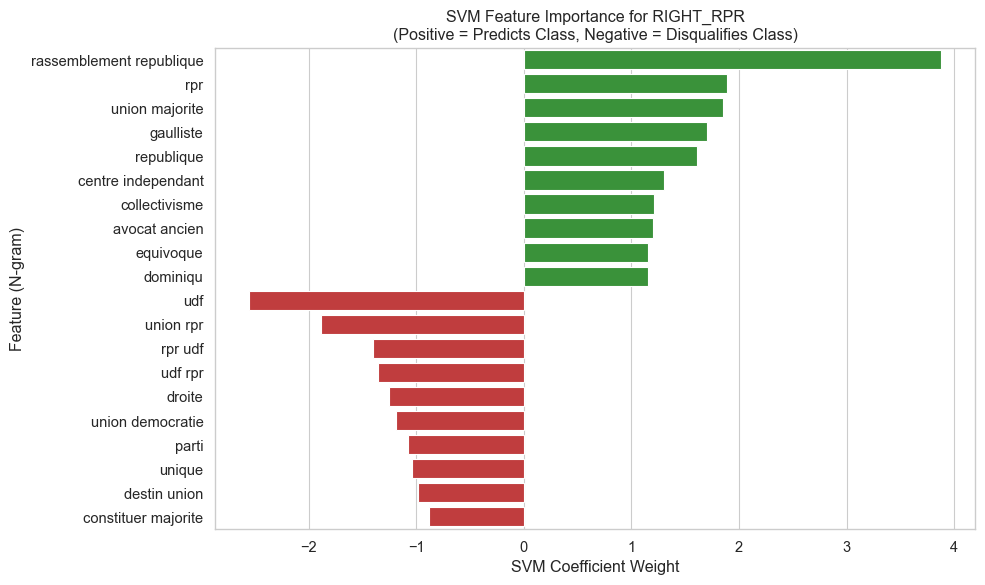

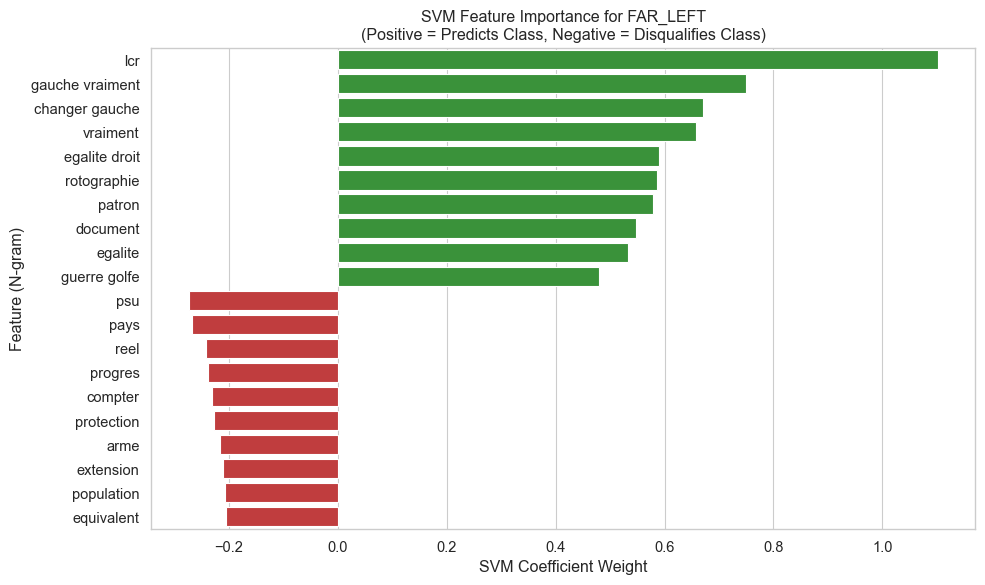

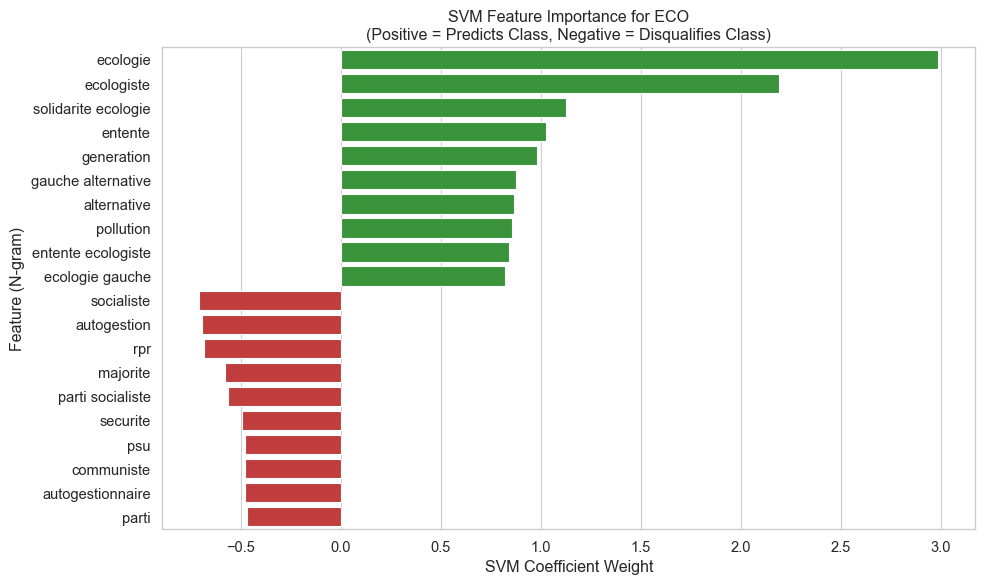

In [ ]:
def plot_svm_feature_importance(
    svm_model, feature_names, classes, target_class, top_n=10
):
    # Find the index of the class
    class_idx = np.where(classes == target_class)[0][0]

    # Extract the weight vector for this specific class
    coef = svm_model.coef_[class_idx]

    # Get the indices of the highest positive and lowest negative weights
    top_positive_idx = coef.argsort()[-top_n:][::-1]
    top_negative_idx = coef.argsort()[:top_n]

    # Combine for plotting
    top_indices = np.concatenate([top_positive_idx, top_negative_idx])
    top_features = feature_names[top_indices]
    top_weights = coef[top_indices]

    # Create color map: Green for positive, Red for negative
    colors = ["#2ca02c" if w > 0 else "#d62728" for w in top_weights]

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=top_weights, y=top_features, hue=top_features, palette=colors, legend=False
    )
    plt.title(
        f"SVM Feature Importance for {target_class}\n(Positive = Predicts Class, Negative = Disqualifies Class)"
    )
    plt.xlabel("SVM Coefficient Weight")
    plt.ylabel("Feature (N-gram)")
    plt.tight_layout()
    plt.show()


# Let's look at the exact weights separating the RPR and the Far-Left
feature_names = tfidf.get_feature_names_out()
plot_svm_feature_importance(best_svm, feature_names, classes, "RIGHT_RPR")
plot_svm_feature_importance(best_svm, feature_names, classes, "FAR_LEFT")
plot_svm_feature_importance(best_svm, feature_names, classes, "ECO")

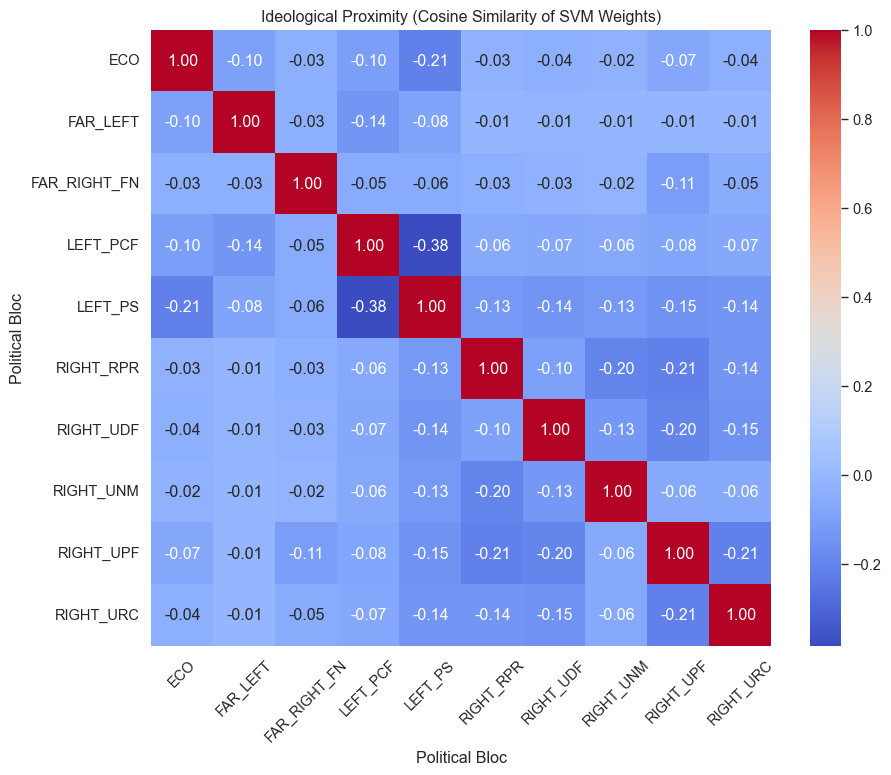

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate the cosine similarity between the weight vectors of all classes
ideological_similarity = cosine_similarity(best_svm.coef_)

plt.figure(figsize=(10, 8))
sns.heatmap(
    ideological_similarity,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    xticklabels=classes,
    yticklabels=classes,
)
plt.title("Ideological Proximity (Cosine Similarity of SVM Weights)")
plt.xlabel("Political Bloc")
plt.ylabel("Political Bloc")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Get the distance to the hyperplane for all test documents
decision_scores = best_svm.decision_function(X_test)

# Find the margin difference between the top choice and the second choice
top_two_indices = np.argsort(decision_scores, axis=1)[:, -2:]
margins = np.abs(
    decision_scores[np.arange(len(decision_scores)), top_two_indices[:, 1]]
    - decision_scores[np.arange(len(decision_scores)), top_two_indices[:, 0]]
)

# Get the index of the text with the SMALLEST margin (the most confusing text)
most_ambiguous_idx = np.argmin(margins)

predicted_class = classes[top_two_indices[most_ambiguous_idx, 1]]
runner_up_class = classes[top_two_indices[most_ambiguous_idx, 0]]
actual_class = y_test[most_ambiguous_idx]

print("--- The Most Ambiguous Manifesto in the Test Set ---")
print(f"Actual Label: {actual_class}")
print(f"Predicted: {predicted_class}")
print(f"Runner-up: {runner_up_class}")
print("\nSnippet of the confusing text:")
# Print the first 1000 characters of this highly ambiguous document
print(X_test_raw.iloc[most_ambiguous_idx][:1000])

--- The Most Ambiguous Manifesto in the Test Set ---
Actual Label: LEFT_PS
Predicted: LEFT_PS
Runner-up: LEFT_PCF

Snippet of the confusing text:
legislative septieme conseiller regional rassemblement progres republicainsmadame remercier confiance septieme affronter upf appeler republicain socialiste communiste radical gauche ecologiste battre droite fondamental valeur progres defendre idee justice social solidarite egalite respect environnement democratie rassembler difference sursaut republicain futur droite histoire representant rpr detenir departement agglomeration acheminer desequilibre precedent exces resulter remise droit social mobilisation progres necessaire placer engagement politique principe integrite tolerance rester service


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Extract feature names and classes from your trained pipeline
feature_names = tfidf.get_feature_names_out()
classes = np.unique(y_train)  # or best_svm.classes_


# ==========================================
# Insight 1: Feature Importance Ledger
# ==========================================
def get_feature_importance_table(svm_model, feature_names, classes, top_n=10):
    """Creates a structured DataFrame of the most polarizing features per class."""
    data = []
    for idx, target_class in enumerate(classes):
        coef = svm_model.coef_[idx]

        # Sort coefficients to find top positive (end of array) and negative (start of array)
        top_pos_idx = coef.argsort()[-top_n:][::-1]
        top_neg_idx = coef.argsort()[:top_n]

        for rank in range(top_n):
            data.append(
                {
                    "Political_Bloc": target_class,
                    "Rank": rank + 1,
                    "Positive_Feature": feature_names[top_pos_idx[rank]],
                    "Pos_Weight": round(coef[top_pos_idx[rank]], 4),
                    "Negative_Feature": feature_names[top_neg_idx[rank]],
                    "Neg_Weight": round(coef[top_neg_idx[rank]], 4),
                }
            )

    return pd.DataFrame(data)


# Generate table and filter for the most interesting classes
importance_df = get_feature_importance_table(best_svm, feature_names, classes, top_n=5)
classes_to_inspect = ["LEFT_PS", "RIGHT_RPR", "RIGHT_UDF", "FAR_RIGHT_FN"]

print("--- 1. Top 5 Polarizing Features Ledger ---")
display(importance_df[importance_df["Political_Bloc"].isin(classes_to_inspect)])


# ==========================================
# Insight 2: The Ideological Proximity Matrix
# ==========================================
# Calculate cosine similarity across the SVM coefficient vectors
similarity_matrix = cosine_similarity(best_svm.coef_)

proximity_df = pd.DataFrame(similarity_matrix, index=classes, columns=classes).round(3)

print("\n--- 2. Ideological Proximity Matrix (Cosine Similarity) ---")
display(proximity_df)


--- 1. Top 5 Polarizing Features Ledger ---


,Political_Bloc,Rank,Positive_Feature,Pos_Weight,Negative_Feature,Neg_Weight
10,FAR_RIGHT_FN,1,immigre,0.8753,union rpr,-0.4102
11,FAR_RIGHT_FN,2,immigration,0.8696,union,-0.3956
12,FAR_RIGHT_FN,3,patrie,0.7833,personne,-0.3443
13,FAR_RIGHT_FN,4,upf,0.7486,construction,-0.3165
14,FAR_RIGHT_FN,5,impot,0.7004,changement,-0.3088
20,LEFT_PS,1,socialiste,2.2595,communiste,-3.6618
21,LEFT_PS,2,parti socialiste,2.1398,union,-2.8764
22,LEFT_PS,3,majorite,1.7569,rpr,-2.5186
23,LEFT_PS,4,alliance progres,1.6255,parti communiste,-2.5138
24,LEFT_PS,5,socialiste majorite,1.5945,ecologie,-1.5998



--- 2. Ideological Proximity Matrix (Cosine Similarity) ---


,ECO,FAR_LEFT,FAR_RIGHT_FN,LEFT_PCF,LEFT_PS,RIGHT_RPR,RIGHT_UDF,RIGHT_UNM,RIGHT_UPF,RIGHT_URC
ECO,1.000,-0.098,-0.033,-0.105,-0.214,-0.032,-0.035,-0.024,-0.071,-0.040
FAR_LEFT,-0.098,1.000,-0.033,-0.135,-0.085,-0.007,-0.011,-0.009,-0.006,-0.006
FAR_RIGHT_FN,-0.033,-0.033,1.000,-0.055,-0.059,-0.033,-0.027,-0.021,-0.111,-0.052
LEFT_PCF,-0.105,-0.135,-0.055,1.000,-0.384,-0.061,-0.066,-0.061,-0.076,-0.067
LEFT_PS,-0.214,-0.085,-0.059,-0.384,1.000,-0.126,-0.143,-0.126,-0.151,-0.136
RIGHT_RPR,-0.032,-0.007,-0.033,-0.061,-0.126,1.000,-0.100,-0.200,-0.215,-0.136
RIGHT_UDF,-0.035,-0.011,-0.027,-0.066,-0.143,-0.100,1.000,-0.134,-0.196,-0.146
RIGHT_UNM,-0.024,-0.009,-0.021,-0.061,-0.126,-0.200,-0.134,1.000,-0.062,-0.060
RIGHT_UPF,-0.071,-0.006,-0.111,-0.076,-0.151,-0.215,-0.196,-0.062,1.000,-0.215
RIGHT_URC,-0.040,-0.006,-0.052,-0.067,-0.136,-0.136,-0.146,-0.060,-0.215,1.000


In [ ]:
import pandas as pd

pd.read_csv("../data/processed/X_test_raw.csv")

,text
0,legislatif quatrieme ueberschlag union rassemb...
1,votez ecologistes rassemblement nature animal ...
2,christian daniel imprimer papier recycler blan...
3,legislatif lutte ouvriere appel faveur lutte o...
4,ecologie democratie ecologie terrain porteur a...
...,...
1617,legislative rpr capitale resultat dependre por...
1618,legislative sincerite jeunesse dernier rpr lai...
1619,humain entente ecologiste generation ecologie ...
1620,egalite fraternite legislative ingenieur centr...


EL135_L_1981_06_059_20_1_PF_01 | x=7.775851, y=9.296847 | LEFT_PCF (Correct)

EL195_L_1993_03_075_03_1_PF_04 | x=21.53785, y=−0.8921685 | LEFT_PS (Misclassified)

EL197_L_1993_03_091_06_1_PF_04 | x=12.63745, y=−2.770114 | RIGHT_RPR (Misclassified)

EL174_L_1988_06_015_02_1_PF_04 | x=10.34415, y=0.7245472 | LEFT_PCF (Correct)

EL191_L_1993_03_033_11_2_PF_01 | x=10.44346, y=1.177862 | RIGHT_UPF (Correct)

EL135_L_1981_06_050_03_1_PF_02 | x=10.7312, y=1.109393 | LEFT_PS (Correct)

**Status Update:** 
Your agenda for tomorrow reads like an undergraduate brainstorming session rather than a formalized experimental protocol. You must mathematically define your metrics for "temporal drift" and "feature importance" before executing a single line of code, or you risk generating analytically bankrupt artifacts.

**Reviewer Notes:**

*   **Outlier Convergence Protocol (Task B & C):** Visually isolated points ($\mathcal{O}_{vis}$) and strictly statistical anomalies ($\mathcal{O}_{stat}$ where $LOF > \tau$) are rarely perfectly overlapping sets due to the non-linear dimensional compression of UMAP. Your inspection code must empirically quantify the intersection $\mathcal{O}_{vis} \cap \mathcal{O}_{stat}$ and explicitly dismiss instances where $\mathbf{x}_i \in \mathcal{O}_{vis} \setminus \mathcal{O}_{stat}$ as mere projection artifacts.
*   **SVM Feature Extraction Formalization (Task A & B):** Because your baseline SVM utilizes a linear kernel, feature importance is not a black-box heuristic; it is the strict weight matrix $\mathbf{W} \in \mathbb{R}^{C \times V}$. For each political bloc $c$, you must extract the top $K$ features by sorting the coefficient magnitudes $|w_{c, j}|$. Be prepared to address collinearity—highly correlated TF-IDF unigrams will distribute the weight, potentially suppressing the apparent importance of key ideological terms.
*   **Quantifying Temporal Drift via SVM (Task A & C):** "Trying temporal drift" is computationally vague. If your goal is to measure concept drift via the decision boundary, you must implement temporal cross-validation. Train the SVM strictly on $t_1$ (e.g., 1981) and evaluate zero-shot performance on $t_2$ (1988) and $t_3$ (1993). Report the macro-$F_1$ decay $\Delta F_1 = F_1(t_1) - F_1(t_{n})$. A steep degradation mathematically proves that the semantic vocabulary defining a political faction shifted drastically between elections.
*   **Actionable Implementation:** Do not simply print the SVM coefficients. Construct a structured DataFrame mapping the top 20 predictive tokens (and their strict scalar weights) for each class, and cross-reference these tokens against the Out-Of-Vocabulary (OOV) rate you established today. A high-weight feature is useless if it is merely a persistent OCR spelling error specific to one party's digitization batch.

### 1. Progress Against the Official Rubric
* **✅ Define a problem:** Predicting political affiliation based on textual rhetoric.
* **✅ Retrieve, format, describe data:** Your `main.py` orchestrator handles extraction, the `ArchelecPreprocessor` handles formatting, and `preprocessing_analysis.py` beautifully handles the statistical description (lengths, class balance, n-gram signatures).
* **⏳ Search the literature (State of the Art):** We haven't written this yet. When you are ready, I can help you draft this section, contrasting classical "Bag of Words" approaches in political science with modern Transformer-based contextual NLP.
* **✅ Propose and justify models:** We have the perfect narrative. A highly regularized SVM baseline (justified for sparse, high-dimensional text) vs. CamemBERT (justified for capturing contextual and syntactic nuance).
* **⏳ Experiment:** Currently underway!
* **⏳ Analyze and conclude:** We will write this once the final CamemBERT metrics are in.


Here is a roadmap for **Future You**. It’s designed to be pasted directly into a `README.md` or a "Next Steps" markdown file so you can pick up exactly where we left off.

---

# 🚩 Project Status & Roadmap: Political Manifesto NLP

### 📍 Current Progress Summary
We have successfully built a robust preprocessing pipeline and established a **TF-IDF + SVM baseline (83% Macro F1)**. We also proved that **Zero-Shot LLMs** struggle with historical nuance (35% F1), but a **CamemBERT Linear Probe** using **processed text** and **class weights** is currently the leading contender for the deep learning path.

---

### 1. The Visual North Star: U-MAP Mapping
The first priority upon return is to generate the **2D Semantic Landscape**.
* **Goal:** Use the saved 768D CamemBERT embeddings to create a U-MAP projection.
* **Why:** This "ideological galaxy" will visually define how the parties distinguish themselves before we look at classification scores.
* **Metric:** Use the **Trustworthiness** sensitivity analysis to ensure the 2D map is mathematically honest to the original high-dimensional space.

### 2. The Classifier Showdown
We are comparing three distinct generations of NLP:
1.  **Classical ML:** Linear SVM (The high-performing baseline).
2.  **Zero-Shot LLM:** mDeBERTa (Measuring "out-of-the-box" political knowledge).
3.  **Linear Probe LLM:** Frozen CamemBERT + Trainable Head (The contextual compromise).
* *Note:* We found that the Linear Probe performs better on **processed/lemmatized text** because the frozen base acts as a superior keyword extractor.

### 3. Error Analysis: Confusion Matrix vs. U-MAP
Once the best model is locked in, we will perform a "Cross-Validation of Intuition":
* Compare the **Confusion Matrix** (where the model fails) to the **U-MAP** (where clusters overlap).
* If the SVM confuses RPR and UDF, and the U-MAP shows them as a single merged cloud, we have successfully proven they "speak the same language."

### 4. The Research Pivot: Ideological Drift
Using the best-performing model architecture, we will measure how the political center of gravity shifted between **1981 and 1988**.
* **Method:** Train on 1981 data and predict 1988 manifestos. 
* **Insight:** Identify which 1988 candidates are "rhetorical ghosts" of 1981 parties.

### 5. Appendix: The Official Labels
As a final robustness check, we will re-run the classification using the **Official Nuance Politique** labels from the *Ministère de l'Intérieur* to see if state-defined categories are more linearly separable than our custom blocs.

---

### 🛠 The "To-Do" List (Technical Debt)

#### **Refactoring to Production (`.py` files)**
* [ ] **`src/features/build_embeddings.py`**: A clean script to generate and save CamemBERT embeddings.
* [ ] **`src/visualization/generate_umap.py`**: Move the U-MAP + Trustworthiness grid search from the notebook to a script that saves an interactive Plotly HTML.
* [ ] **`src/models/train_transformer_probe.py`**: Convert the Linear Probe notebook into a production script with `WeightedTrainer` and `EarlyStopping`.

#### **New Development**
* [ ] **Confusion Matrix Logic**: Write a utility to export detailed per-class metrics and heatmaps for the final report.
* [ ] **Drift Analysis Script**: Create a specialized split-by-year training script to measure temporal shifts.
* [ ] **Appendix Pipeline**: A simple wrapper to toggle the `target_label` to `nuance_politique` and re-run the SVM/Probe.

---

**Current Save Point:** Embeddings and indices are saved as `.npy` files in `data/processed/`. You can skip the heavy LLM inference next time!

**Enjoy the break—the M4 is ready when you are.**

Controlling for Sparsity Artifacts: Be prepared to demonstrate that your top SVM features f 
j
​	
  are not merely artifacts of the inverse document frequency scaling idf(t,D)=log 
∣{d∈D:t∈d}∣
N
​	
  amplifying rare OCR noise. Cross-reference your top K tokens against the global Out-Of-Vocabulary (OOV) rate.

In [63]:
import pandas as pd

df = pd.read_csv("../reports/metrics/camembert_lof_outlier_scores.csv")

In [64]:
df[df["split"] == "test"].sort_values("LOF_Score", ascending=False).head(40)

,original_id,date,titulaire-soutien,target_label,split,LOF_Score,is_statistical_outlier
6,EL191_L_1993_03_033_11_2_PF_01,1993-03-28,Union pour la démocratie française;Rassembleme...,RIGHT_UPF,test,7.790802,True
11,EL137_L_1981_06_080_03_1_PF_04,1981-06-14,Mouvement des radicaux de gauche;gaullistes de...,LEFT_PS,test,7.184435,True
18,EL176_L_1988_06_068_03_1_PF_01,1988-06-05,Front national,FAR_RIGHT_FN,test,6.772834,True
29,EL198_L_1993_03_092_01_1_PF_02,1993-03-21,Front national,FAR_RIGHT_FN,test,6.170917,True
30,EL196_L_1993_03_080_02_1_PF_03,1993-03-21,Parti socialiste,LEFT_PS,test,5.771951,True
37,EL174_L_1988_06_015_02_1_PF_04,1988-06-05,Parti communiste français,LEFT_PCF,test,5.346232,True
46,EL191_L_1993_03_034_03_2_PF_02,1993-03-28,Union pour la démocratie française;Rassembleme...,RIGHT_UPF,test,5.057054,True
47,EL174_L_1988_06_013_07_2_PF_02,1988-06-12,Front national,FAR_RIGHT_FN,test,5.055841,True
48,EL189_L_1993_03_013_07_2_PF_01,1993-03-28,Front national,FAR_RIGHT_FN,test,5.021186,True
52,EL135_L_1981_06_050_03_1_PF_02,1981-06-14,Socialistes,LEFT_PS,test,4.914798,True


In [58]:
len(df[df["split"] == "test"][df["is_statistical_outlier"] == True])

/var/folders/l4/rqys14ws2955nprxbdsj722r0000gn/T/ipykernel_38153/1698893156.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  len(df[df["split"]=="test"][df["is_statistical_outlier"]==True])


35

In [66]:
df[df["split"] == "test"][df["is_statistical_outlier"] == True].groupby(
    ["target_label"]
).count()

/var/folders/l4/rqys14ws2955nprxbdsj722r0000gn/T/ipykernel_38153/1511017077.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df["split"]=="test"][df["is_statistical_outlier"]==True].groupby(["target_label"]).count()


,original_id,date,titulaire-soutien,split,LOF_Score,is_statistical_outlier
target_label,,,,,,
FAR_LEFT,1,1,1,1,1,1
FAR_RIGHT_FN,14,14,14,14,14,14
LEFT_PCF,6,6,6,6,6,6
LEFT_PS,3,3,3,3,3,3
RIGHT_RPR,2,2,2,2,2,2
RIGHT_UDF,2,2,2,2,2,2
RIGHT_UPF,3,3,3,3,3,3
RIGHT_URC,4,4,4,4,4,4


In [67]:
import pandas as pd

df = pd.read_csv("../reports/metrics/outliers_analysis.csv")

In [69]:
df.groupby(["True_Label_y", "Diagnostic_Heuristic"]).count()

Document_ID  \
True_Label_y Diagnostic_Heuristic                                              
FAR_LEFT     Intra-class Outlier. Visually isolated but sema...            1   
FAR_RIGHT_FN Intra-class Outlier. Visually isolated but sema...           13   
             Topological isolation driven by OCR degradation.              1   
LEFT_PCF     Intra-class Outlier. Visually isolated but sema...            7   
LEFT_PS      Intra-class Outlier. Visually isolated but sema...            3   
             True Anomaly. Boundary misclassification corrob...            1   
RIGHT_RPR    Intra-class Outlier. Visually isolated but sema...            2   
             True Anomaly. Boundary misclassification corrob...            1   
RIGHT_UDF    Intra-class Outlier. Visually isolated but sema...            2   
RIGHT_UPF    Intra-class Outlier. Visually isolated but sema...            3   
RIGHT_URC    Intra-class Outlier. Visually isolated but sema...            4   

                                                                 Subset_Origin  \
True_Label_y Diagnostic_Heuristic                                                
FAR_LEFT     Intra-class Outlier. Visually isolated but sema...              1   
FAR_RIGHT_FN Intra-class Outlier. Visually isolated but sema...             13   
             Topological isolation driven by OCR degradation.                1   
LEFT_PCF     Intra-class Outlier. Visually isolated but sema...              7   
LEFT_PS      Intra-class Outlier. Visually isolated but sema...              3   
             True Anomaly. Boundary misclassification corrob...              1   
RIGHT_RPR    Intra-class Outlier. Visually isolated but sema...              2   
             True Anomaly. Boundary misclassification corrob...              1   
RIGHT_UDF    Intra-class Outlier. Visually isolated but sema...              2   
RIGHT_UPF    Intra-class Outlier. Visually isolated but sema...              3   
RIGHT_URC    Intra-class Outlier. Visually isolated but sema...              4   

                                                                 Date  \
True_Label_y Diagnostic_Heuristic                                       
FAR_LEFT     Intra-class Outlier. Visually isolated but sema...     1   
FAR_RIGHT_FN Intra-class Outlier. Visually isolated but sema...    13   
             Topological isolation driven by OCR degradation.       1   
LEFT_PCF     Intra-class Outlier. Visually isolated but sema...     7   
LEFT_PS      Intra-class Outlier. Visually isolated but sema...     3   
             True Anomaly. Boundary misclassification corrob...     1   
RIGHT_RPR    Intra-class Outlier. Visually isolated but sema...     2   
             True Anomaly. Boundary misclassification corrob...     1   
RIGHT_UDF    Intra-class Outlier. Visually isolated but sema...     2   
RIGHT_UPF    Intra-class Outlier. Visually isolated but sema...     3   
RIGHT_URC    Intra-class Outlier. Visually isolated but sema...     4   

                                                                 Official_Party  \
True_Label_y Diagnostic_Heuristic                                                 
FAR_LEFT     Intra-class Outlier. Visually isolated but sema...               1   
FAR_RIGHT_FN Intra-class Outlier. Visually isolated but sema...              13   
             Topological isolation driven by OCR degradation.                 1   
LEFT_PCF     Intra-class Outlier. Visually isolated but sema...               7   
LEFT_PS      Intra-class Outlier. Visually isolated but sema...               3   
             True Anomaly. Boundary misclassification corrob...               1   
RIGHT_RPR    Intra-class Outlier. Visually isolated but sema...               2   
             True Anomaly. Boundary misclassification corrob...               1   
RIGHT_UDF    Intra-class Outlier. Visually isolated but sema...               2   
RIGHT_UPF    Intra-class Outlier. Visually isolated but sema...               3   
RIGHT_URC  